##Import Libraries



In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

##Define your Websites

In [2]:
websites = {
    "TechCrunch": "https://techcrunch.com/",
    "CNN": "https://www.cnn.com/",
    "The Guardian": "https://www.theguardian.com/",
    "NDTV": "https://www.ndtv.com/",
    "GeeksforGeeks": "https://www.geeksforgeeks.org/",
    "Investopedia": "https://www.investopedia.com/"
}

##Fetch their HTML

In [3]:
data = []

for name, url in websites.items():

    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        soup = BeautifulSoup(response.text, "html.parser")

        data.append({
            "Website": name,
            "URL": url,
            "Status Code": response.status_code,
            "HTML Size": len(response.text),
            "Number of Links": len(soup.find_all("a")),
            "Number of Images": len(soup.find_all("img")),
            "Number of Scripts": len(soup.find_all("script"))
        })

    except Exception as e:
        print(name, e)

df = pd.DataFrame(data)

df

,Website,URL,Status Code,HTML Size,Number of Links,Number of Images,Number of Scripts
0,TechCrunch,https://techcrunch.com/,200,455205,319,73,42
1,CNN,https://www.cnn.com/,200,5595317,486,78,12
2,The Guardian,https://www.theguardian.com/,200,1301693,343,115,19
3,NDTV,https://www.ndtv.com/,403,366,0,0,0
4,GeeksforGeeks,https://www.geeksforgeeks.org/,200,119148,90,13,20
5,Investopedia,https://www.investopedia.com/,402,612,4,0,0


##Detect Advertising-Related Elements

In [4]:
ad_keywords = [
    "ads",
    "advertisement",
    "googleadservices",
    "googlesyndication",
    "doubleclick",
    "adservice",
    "adsbygoogle"
]


def detect_ads(html):

    html_lower = html.lower()

    found = []

    for keyword in ad_keywords:
        if keyword in html_lower:
            found.append(keyword)

    return found


# Create an empty list to store results
results = []


for name, url in websites.items():

    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        detected = detect_ads(response.text)

        results.append({
            "Website": name,
            "URL": url,
            "Ad Indicators": ", ".join(detected),
            "Ad Indicator Count": len(detected)
        })

    except Exception as e:
        print(name, e)


ad_df = pd.DataFrame(results)

ad_df

,Website,URL,Ad Indicators,Ad Indicator Count
0,TechCrunch,https://techcrunch.com/,ads,1
1,CNN,https://www.cnn.com/,"ads, advertisement, googlesyndication, doublec...",4
2,The Guardian,https://www.theguardian.com/,"ads, doubleclick",2
3,NDTV,https://www.ndtv.com/,,0
4,GeeksforGeeks,https://www.geeksforgeeks.org/,ads,1
5,Investopedia,https://www.investopedia.com/,,0


##Analyze the website structure

In [5]:
df["Link Density"] = df["Number of Links"] / df["HTML Size"]

df["Image Density"] = df["Number of Images"] / df["HTML Size"]

final_df = df.merge(
    ad_df[["Website", "Ad Indicator Count"]],
    on="Website"
)

final_df

,Website,URL,Status Code,HTML Size,Number of Links,Number of Images,Number of Scripts,Link Density,Image Density,Ad Indicator Count
0,TechCrunch,https://techcrunch.com/,200,455205,319,73,42,0.000701,0.000160,1
1,CNN,https://www.cnn.com/,200,5595317,486,78,12,0.000087,0.000014,4
2,The Guardian,https://www.theguardian.com/,200,1301693,343,115,19,0.000264,0.000088,2
3,NDTV,https://www.ndtv.com/,403,366,0,0,0,0.000000,0.000000,0
4,GeeksforGeeks,https://www.geeksforgeeks.org/,200,119148,90,13,20,0.000755,0.000109,1
5,Investopedia,https://www.investopedia.com/,402,612,4,0,0,0.006536,0.000000,0


##Estimate Advertising Impact

In [6]:
#Assuming number of monthly visitors
monthly_visitors = {
    "TechCrunch": 500000,
    "CNN": 2000000,
    "The Guardian": 1500000,
    "NDTV": 1200000,
    "GeeksforGeeks": 1000000,
    "Investopedia": 1800000
}

final_df["Monthly Visitors"] = final_df["Website"].map(monthly_visitors)

AVG_AD_VIEWS = 3

final_df["Estimated Ad Impressions"] = (
    final_df["Monthly Visitors"] * AVG_AD_VIEWS
)

final_df

,Website,URL,Status Code,HTML Size,Number of Links,Number of Images,Number of Scripts,Link Density,Image Density,Ad Indicator Count,Monthly Visitors,Estimated Ad Impressions
0,TechCrunch,https://techcrunch.com/,200,455205,319,73,42,0.000701,0.000160,1,500000,1500000
1,CNN,https://www.cnn.com/,200,5595317,486,78,12,0.000087,0.000014,4,2000000,6000000
2,The Guardian,https://www.theguardian.com/,200,1301693,343,115,19,0.000264,0.000088,2,1500000,4500000
3,NDTV,https://www.ndtv.com/,403,366,0,0,0,0.000000,0.000000,0,1200000,3600000
4,GeeksforGeeks,https://www.geeksforgeeks.org/,200,119148,90,13,20,0.000755,0.000109,1,1000000,3000000
5,Investopedia,https://www.investopedia.com/,402,612,4,0,0,0.006536,0.000000,0,1800000,5400000


##Estimate Marketing and Revenue Impact

In [7]:
# Assumed Click Through Rate
CTR = 0.02

final_df["Estimated Clicks"] = (
    final_df["Estimated Ad Impressions"] * CTR
)

final_df

,Website,URL,Status Code,HTML Size,Number of Links,Number of Images,Number of Scripts,Link Density,Image Density,Ad Indicator Count,Monthly Visitors,Estimated Ad Impressions,Estimated Clicks
0,TechCrunch,https://techcrunch.com/,200,455205,319,73,42,0.000701,0.000160,1,500000,1500000,30000.0
1,CNN,https://www.cnn.com/,200,5595317,486,78,12,0.000087,0.000014,4,2000000,6000000,120000.0
2,The Guardian,https://www.theguardian.com/,200,1301693,343,115,19,0.000264,0.000088,2,1500000,4500000,90000.0
3,NDTV,https://www.ndtv.com/,403,366,0,0,0,0.000000,0.000000,0,1200000,3600000,72000.0
4,GeeksforGeeks,https://www.geeksforgeeks.org/,200,119148,90,13,20,0.000755,0.000109,1,1000000,3000000,60000.0
5,Investopedia,https://www.investopedia.com/,402,612,4,0,0,0.006536,0.000000,0,1800000,5400000,108000.0


In [8]:
# Assumed Cost Per Thousand Impressions
CPM = 2.50

final_df["Estimated Revenue"] = (
    final_df["Estimated Ad Impressions"] / 1000
) * CPM

final_df

,Website,URL,Status Code,HTML Size,Number of Links,Number of Images,Number of Scripts,Link Density,Image Density,Ad Indicator Count,Monthly Visitors,Estimated Ad Impressions,Estimated Clicks,Estimated Revenue
0,TechCrunch,https://techcrunch.com/,200,455205,319,73,42,0.000701,0.000160,1,500000,1500000,30000.0,3750.0
1,CNN,https://www.cnn.com/,200,5595317,486,78,12,0.000087,0.000014,4,2000000,6000000,120000.0,15000.0
2,The Guardian,https://www.theguardian.com/,200,1301693,343,115,19,0.000264,0.000088,2,1500000,4500000,90000.0,11250.0
3,NDTV,https://www.ndtv.com/,403,366,0,0,0,0.000000,0.000000,0,1200000,3600000,72000.0,9000.0
4,GeeksforGeeks,https://www.geeksforgeeks.org/,200,119148,90,13,20,0.000755,0.000109,1,1000000,3000000,60000.0,7500.0
5,Investopedia,https://www.investopedia.com/,402,612,4,0,0,0.006536,0.000000,0,1800000,5400000,108000.0,13500.0


##Visualisize the Results

###Advertising Presence

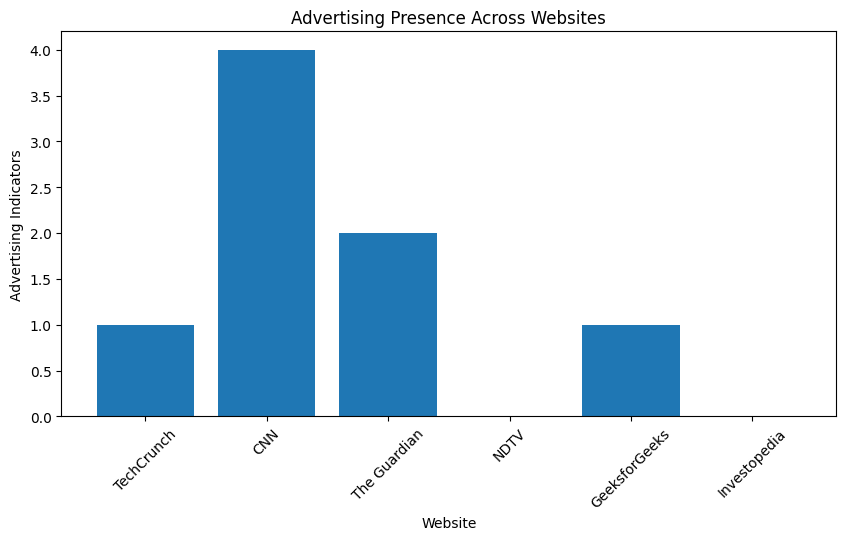

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_df["Website"],
    final_df["Ad Indicator Count"]
)

plt.xlabel("Website")
plt.ylabel("Advertising Indicators")
plt.title("Advertising Presence Across Websites")

plt.xticks(rotation=45)
plt.show()

###Estimated Impressions

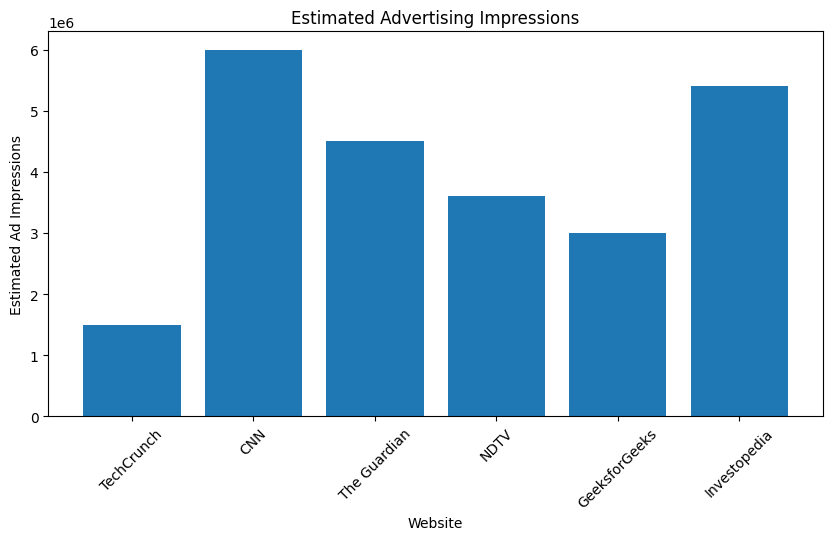

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_df["Website"],
    final_df["Estimated Ad Impressions"]
)

plt.xlabel("Website")
plt.ylabel("Estimated Ad Impressions")
plt.title("Estimated Advertising Impressions")

plt.xticks(rotation=45)
plt.show()

###Estimated Clicks

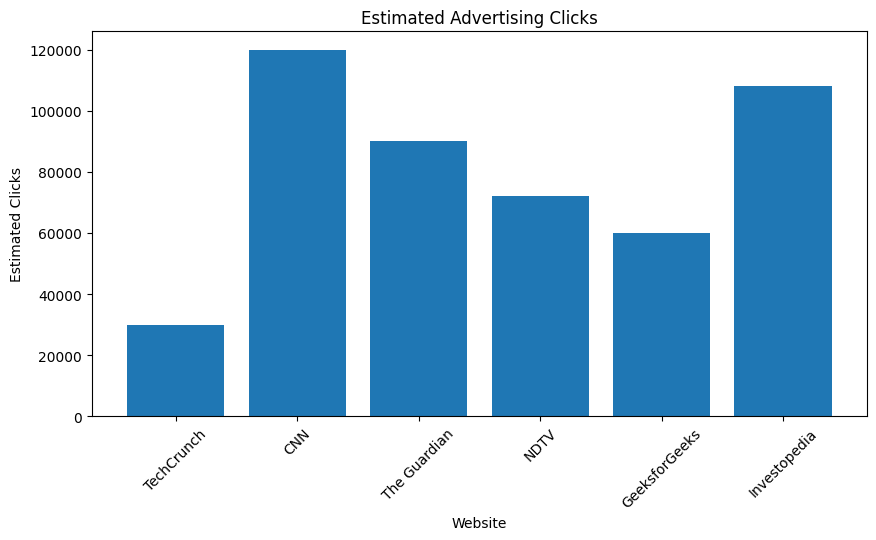

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_df["Website"],
    final_df["Estimated Clicks"]
)

plt.xlabel("Website")
plt.ylabel("Estimated Clicks")
plt.title("Estimated Advertising Clicks")

plt.xticks(rotation=45)
plt.show()

###Estimated Revenue

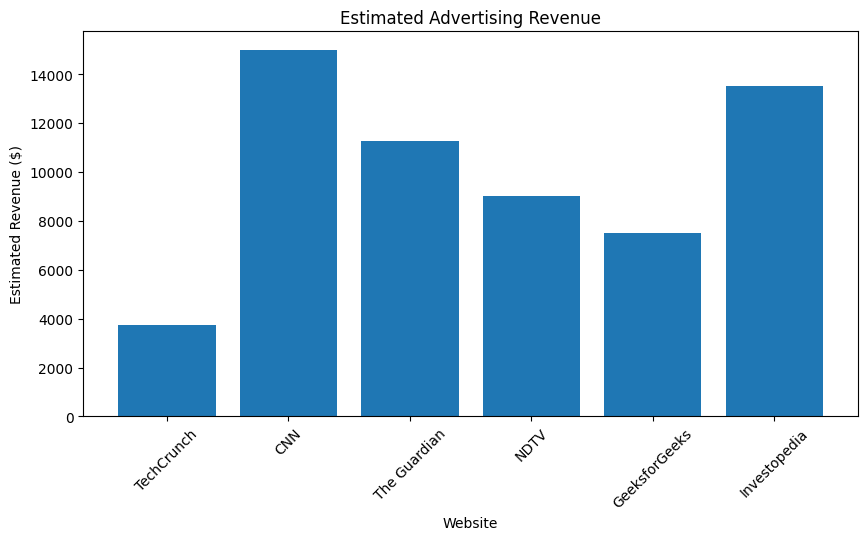

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_df["Website"],
    final_df["Estimated Revenue"]
)

plt.xlabel("Website")
plt.ylabel("Estimated Revenue ($)")
plt.title("Estimated Advertising Revenue")

plt.xticks(rotation=45)
plt.show()